<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/02_april_Logistic_Regression_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Science Masters

In [1]:
# ── Global Imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.datasets import (load_breast_cancer, load_iris,
                               make_classification, load_digits)
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, KFold)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay,
    matthews_corrcoef, balanced_accuracy_score)
from scipy.stats import randint, uniform
import time

# ── Plot Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titleweight'  : 'bold',
})
C1, C2, C3, C4 = '#4C72B0', '#DD8452', '#55A868', '#C44E52'

print('✓  All libraries imported successfully')

✓  All libraries imported successfully


---
## Q1. Purpose of GridSearchCV and How It Works
### Theory

### What is GridSearchCV?

**GridSearchCV** is a hyperparameter tuning technique that **exhaustively searches** over a manually specified grid of hyperparameter values and selects the combination that yields the best cross-validated score.

### Why is it needed?
Machine learning models have **hyperparameters** (set before training, e.g., `C` in SVM, `max_depth` in Decision Tree) that significantly impact performance.  
Manually trying every combination is tedious and error-prone — GridSearchCV automates this systematically.

### How it works — Step by Step:

1. **Define** a parameter grid: `{C: [0.1, 1, 10], kernel: ['rbf', 'linear']}`  
2. **Enumerate** all combinations: (0.1, rbf), (0.1, linear), (1, rbf), … → **n combinations**  
3. **For each combination:** run K-Fold Cross-Validation (default cv=5)  
4. **Compute** mean CV score across all folds  
5. **Select** the combination with the highest mean CV score  
6. **Refit** the model on the full training set using the best parameters  

**Total model fits = (number of param combinations) × (number of CV folds)**

For example: 3 values of C × 2 kernels = 6 combinations × 5 folds = **30 model fits**

Total combinations : 20
Total model fits   : 20 × 5 folds = 100

Best Parameters : {'svc__C': 0.01, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV Score   : 0.9765
Test Accuracy   : 0.9580
Search Time     : 9.83s


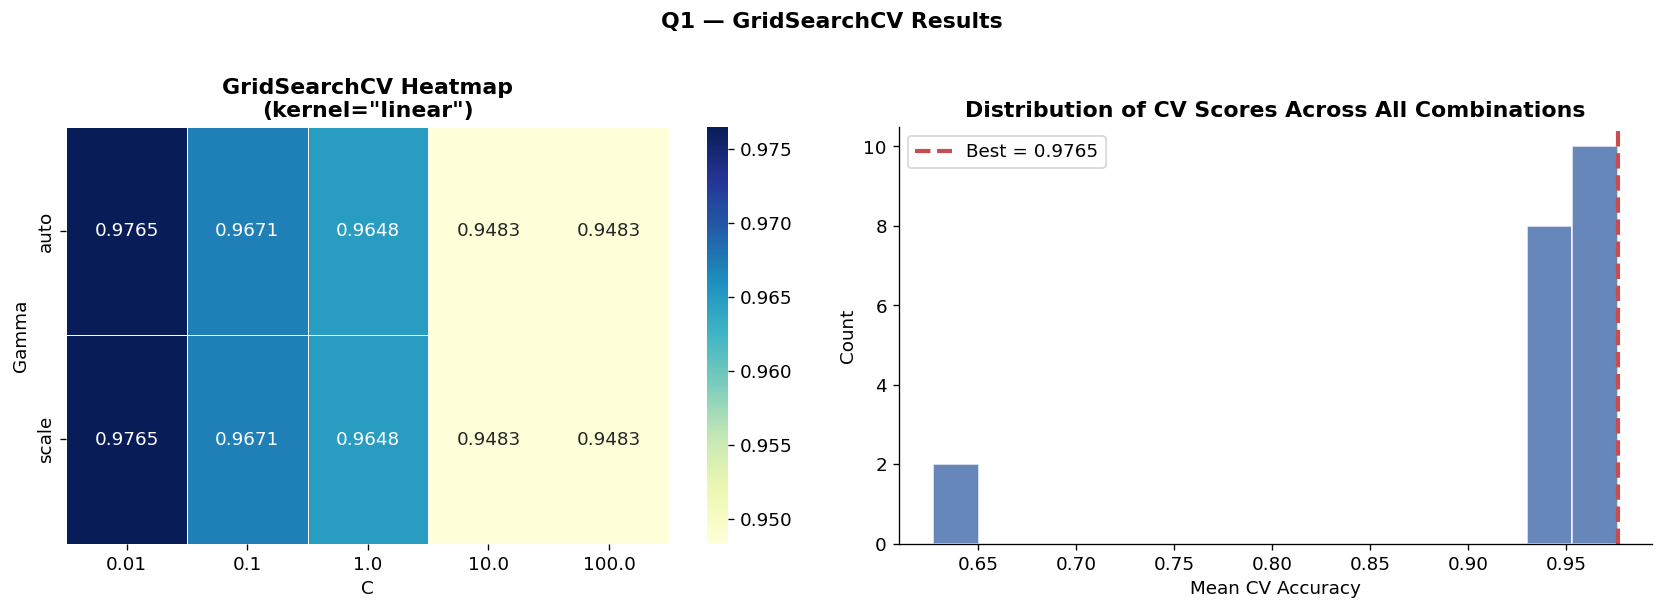

In [2]:
# ── Q1: GridSearchCV Demo ──────────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Scale inside a Pipeline to avoid leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(probability=True))
])

param_grid = {
    'svc__C'     : [0.01, 0.1, 1, 10, 100],
    'svc__kernel': ['rbf', 'linear'],
    'svc__gamma' : ['scale', 'auto']
}

n_combos = (len(param_grid['svc__C']) *
            len(param_grid['svc__kernel']) *
            len(param_grid['svc__gamma']))
print(f'Total combinations : {n_combos}')
print(f'Total model fits   : {n_combos} × 5 folds = {n_combos * 5}')

t0 = time.time()
grid_search = GridSearchCV(pipe, param_grid, cv=5,
                            scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_:.4f}')
print(f'Test Accuracy   : {grid_search.score(X_test, y_test):.4f}')
print(f'Search Time     : {elapsed:.2f}s')

# ── Visualize CV results as a heatmap (C vs gamma, best kernel) ────────────────
results   = pd.DataFrame(grid_search.cv_results_)
best_kern = grid_search.best_params_['svc__kernel']
subset    = results[results['param_svc__kernel'] == best_kern].copy()
subset['C']     = subset['param_svc__C'].astype(float)
subset['gamma'] = subset['param_svc__gamma'].astype(str)

pivot = subset.pivot_table(
    index='gamma', columns='C', values='mean_test_score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            ax=axes[0], linewidths=0.5)
axes[0].set(title=f'GridSearchCV Heatmap\n(kernel="{best_kern}")',
            xlabel='C', ylabel='Gamma')

# Distribution of all CV mean scores
axes[1].hist(results['mean_test_score'], bins=15,
             color=C1, edgecolor='white', alpha=0.85)
axes[1].axvline(grid_search.best_score_, color=C4, lw=2.5,
                ls='--', label=f'Best = {grid_search.best_score_:.4f}')
axes[1].set(title='Distribution of CV Scores Across All Combinations',
            xlabel='Mean CV Accuracy', ylabel='Count')
axes[1].legend()

plt.suptitle('Q1 — GridSearchCV Results', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Q2. GridSearchCV vs RandomizedSearchCV
### Theory

| Feature | **GridSearchCV** | **RandomizedSearchCV** |
|---|---|---|
| Search strategy | Exhaustive — tries **every** combination | Random — samples `n_iter` combinations |
| Parameter space | Discrete lists only | Lists **or continuous distributions** |
| Computation | O(n_params × folds) — grows exponentially | Fixed: O(n_iter × folds) |
| Guarantee | Finds the best in the grid | Probabilistic — may miss best |
| Best when | Small param space, ample compute | Large/continuous param space, time constraints |
| Key param | `param_grid` (dict of lists) | `param_distributions` (dict of lists/distributions) |

### When to choose which?

**Use GridSearchCV when:**
- You have ≤ 3–4 hyperparameters with a few discrete values each
- Compute time is not a constraint
- You need to be certain about the optimal combination

**Use RandomizedSearchCV when:**
- You have many hyperparameters (5+) or continuous ranges
- Compute budget is limited
- You want to explore a wider space quickly (often finds near-optimal much faster)

> **Research insight (Bergstra & Bengio, 2012):** Random search is more efficient than grid search because in most models, only a few hyperparameters matter — random search explores more values of the important ones.

GridSearchCV    : 36 combinations × 5 folds = 180 fits
RandomizedSearch: 20  combinations × 5 folds = 100 fits

GridSearchCV     → Best CV: 0.9601 | Test: 0.9580 | Time: 59.22s
RandomizedSearch → Best CV: 0.9648 | Test: 0.9580 | Time: 43.40s


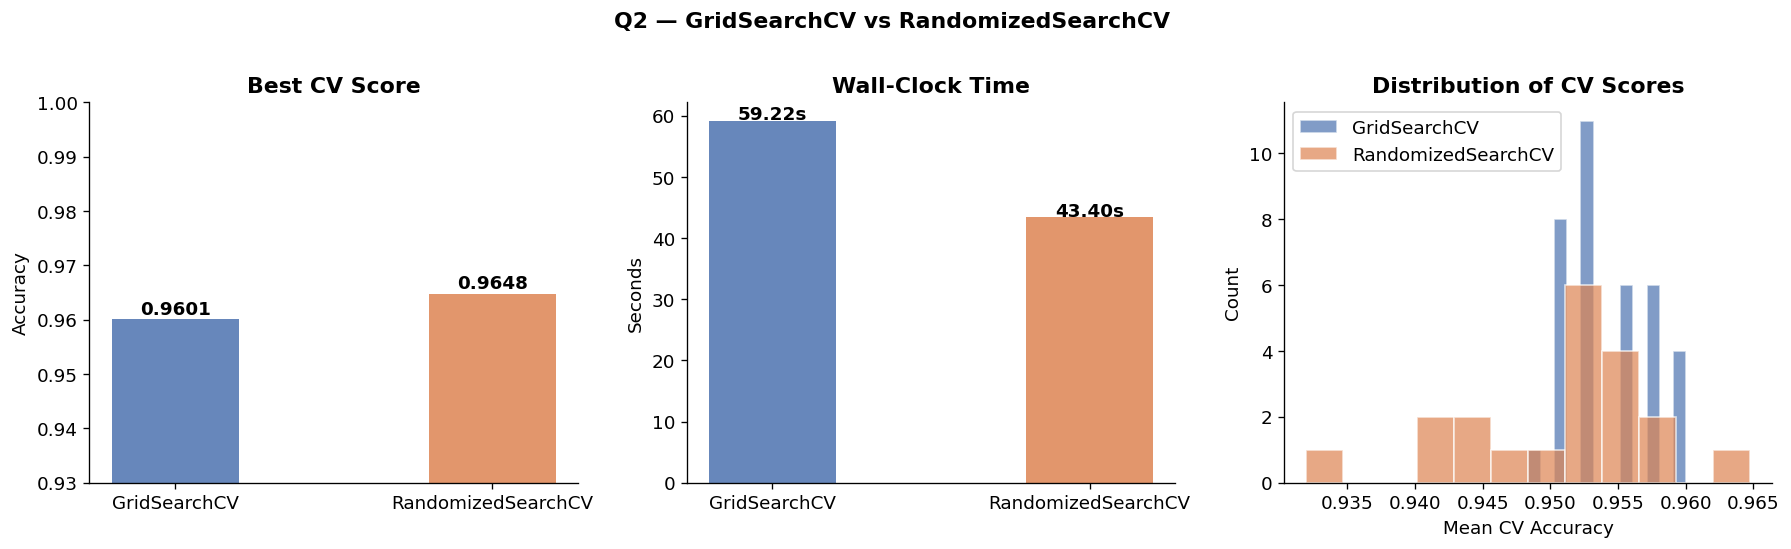

In [3]:
# ── Q2: Grid vs Randomized Search Comparison ──────────────────────────────────
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(random_state=42))
])

# Grid param space
param_grid_rf = {
    'rf__n_estimators' : [50, 100, 200],
    'rf__max_depth'    : [3, 5, 10, None],
    'rf__min_samples_split': [2, 5, 10]
}

# Random param space (same parameters, but continuous distributions)
param_dist_rf = {
    'rf__n_estimators'     : randint(10, 300),
    'rf__max_depth'        : [3, 5, 10, 15, 20, None],
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf' : randint(1, 10),     # extra param not in grid
    'rf__max_features'     : ['sqrt', 'log2', None]
}

n_iter = 20  # RandomizedSearch budget
grid_combos = (len(param_grid_rf['rf__n_estimators']) *
               len(param_grid_rf['rf__max_depth']) *
               len(param_grid_rf['rf__min_samples_split']))

print(f'GridSearchCV    : {grid_combos} combinations × 5 folds = {grid_combos*5} fits')
print(f'RandomizedSearch: {n_iter}  combinations × 5 folds = {n_iter*5} fits')

# --- Run Grid Search ---
t0 = time.time()
gs = GridSearchCV(rf_pipe, param_grid_rf, cv=5,
                  scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)
gs_time = time.time() - t0

# --- Run Randomized Search ---
t0 = time.time()
rs = RandomizedSearchCV(rf_pipe, param_dist_rf, n_iter=n_iter,
                        cv=5, scoring='accuracy',
                        n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
rs_time = time.time() - t0

gs_test = gs.score(X_test, y_test)
rs_test = rs.score(X_test, y_test)

print(f'\nGridSearchCV     → Best CV: {gs.best_score_:.4f} | Test: {gs_test:.4f} | Time: {gs_time:.2f}s')
print(f'RandomizedSearch → Best CV: {rs.best_score_:.4f} | Test: {rs_test:.4f} | Time: {rs_time:.2f}s')

# ── Plot comparison ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# CV Score comparison
ax = axes[0]
methods = ['GridSearchCV', 'RandomizedSearchCV']
cv_scores = [gs.best_score_, rs.best_score_]
bars = ax.bar(methods, cv_scores, color=[C1, C2], alpha=0.85, width=0.4)
for b, v in zip(bars, cv_scores):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}',
            ha='center', fontweight='bold')
ax.set(title='Best CV Score', ylabel='Accuracy', ylim=[0.93, 1.0])

# Time comparison
ax = axes[1]
bars = ax.bar(methods, [gs_time, rs_time], color=[C1, C2], alpha=0.85, width=0.4)
for b, v in zip(bars, [gs_time, rs_time]):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.2f}s',
            ha='center', fontweight='bold')
ax.set(title='Wall-Clock Time', ylabel='Seconds')

# Score distributions
ax = axes[2]
ax.hist(pd.DataFrame(gs.cv_results_)['mean_test_score'],
        bins=12, alpha=0.7, color=C1, label='GridSearchCV', edgecolor='white')
ax.hist(pd.DataFrame(rs.cv_results_)['mean_test_score'],
        bins=12, alpha=0.7, color=C2, label='RandomizedSearchCV', edgecolor='white')
ax.set(title='Distribution of CV Scores', xlabel='Mean CV Accuracy', ylabel='Count')
ax.legend()

plt.suptitle('Q2 — GridSearchCV vs RandomizedSearchCV', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Q3. Data Leakage — Definition, Problem, and Example
### Theory

### What is Data Leakage?

**Data leakage** occurs when information from **outside the training set** (usually from the test/future data) is inadvertently used to train or preprocess the model, causing artificially optimistic performance estimates that do not hold in real-world deployment.

### Why is it a problem?
- The model appears to perform well in evaluation but **fails in production**
- It produces misleading metrics that give false confidence
- Decisions made based on leaked models can be costly or dangerous

### Two Types of Leakage:

| Type | Description | Example |
|---|---|---|
| **Target Leakage** | Features that are consequences of the target (future info) | Using a patient's prescribed medication to predict their diagnosis |
| **Train-Test Contamination** | Preprocessing steps applied to combined train+test data | Fitting a StandardScaler on the entire dataset before splitting |

### Concrete Example — Train-Test Contamination:
```
❌ WRONG (Leaky):
   scaler.fit_transform(X_all)  → split → train/test
   ↑ The scaler has already 'seen' the test data statistics!

✓ CORRECT:
   split → scaler.fit(X_train) → scaler.transform(X_train, X_test)
   ↑ Test data statistics are never used during fitting
```

Leaky  pipeline — Mean Test Accuracy: 0.8019 ± 0.0865
Clean  pipeline — Mean Test Accuracy: 0.8021 ± 0.0866
Inflated accuracy due to leakage   : +-0.02%


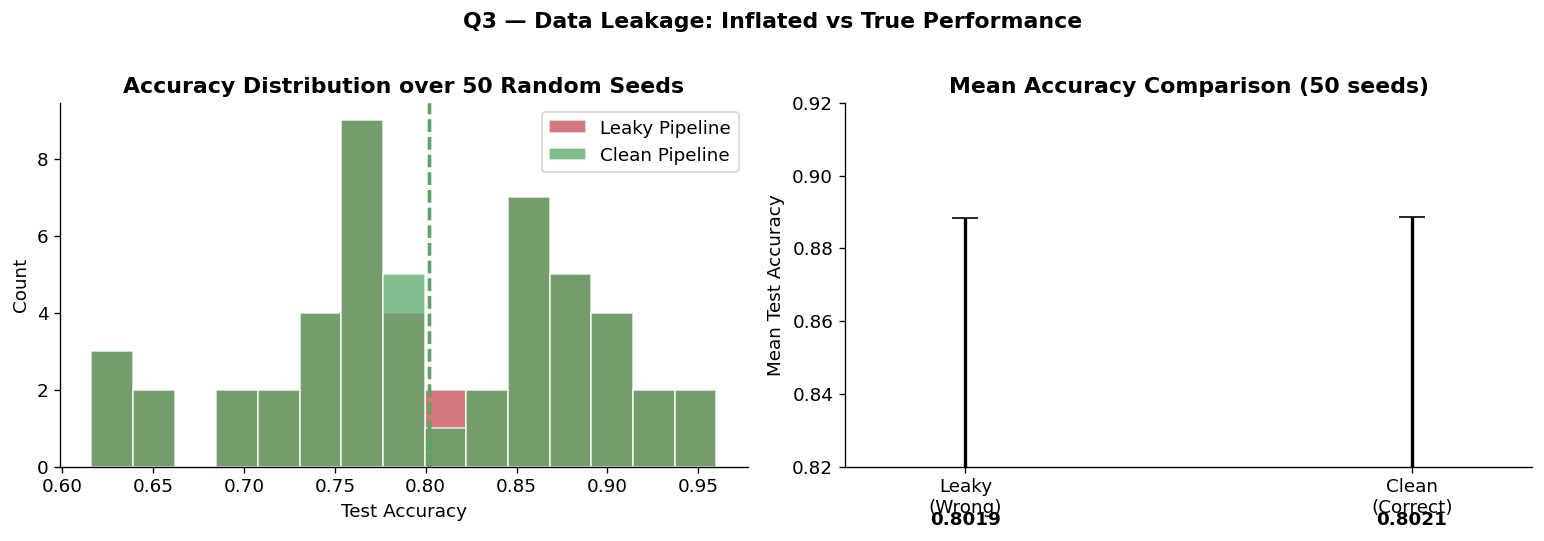

In [4]:
# ── Q3: Demonstrate Data Leakage Effect ───────────────────────────────────────
np.random.seed(42)
n_runs = 50

leaky_scores, clean_scores = [], []

for seed in range(n_runs):
    X_d, y_d = make_classification(n_samples=500, n_features=20,
                                   n_informative=5, random_state=seed)

    # ── LEAKY approach: scale BEFORE split ────────────────────────────────────
    scaler_leak = StandardScaler()
    X_scaled_all = scaler_leak.fit_transform(X_d)          # sees all data!
    Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
        X_scaled_all, y_d, test_size=0.25, random_state=seed)
    mdl_leak = LogisticRegression(max_iter=500)
    mdl_leak.fit(Xl_tr, yl_tr)
    leaky_scores.append(mdl_leak.score(Xl_te, yl_te))

    # ── CLEAN approach: scale AFTER split (inside pipeline) ───────────────────
    Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
        X_d, y_d, test_size=0.25, random_state=seed)
    pipe_clean = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',   LogisticRegression(max_iter=500))
    ])
    pipe_clean.fit(Xc_tr, yc_tr)
    clean_scores.append(pipe_clean.score(Xc_te, yc_te))

leaky_mean = np.mean(leaky_scores)
clean_mean = np.mean(clean_scores)

print(f'Leaky  pipeline — Mean Test Accuracy: {leaky_mean:.4f} ± {np.std(leaky_scores):.4f}')
print(f'Clean  pipeline — Mean Test Accuracy: {clean_mean:.4f} ± {np.std(clean_scores):.4f}')
print(f'Inflated accuracy due to leakage   : +{(leaky_mean - clean_mean)*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(leaky_scores, bins=15, alpha=0.75, color=C4, label='Leaky Pipeline',  edgecolor='white')
ax.hist(clean_scores, bins=15, alpha=0.75, color=C3, label='Clean Pipeline',  edgecolor='white')
ax.axvline(leaky_mean, color=C4, lw=2, ls='--')
ax.axvline(clean_mean, color=C3, lw=2, ls='--')
ax.set(title='Accuracy Distribution over 50 Random Seeds',
       xlabel='Test Accuracy', ylabel='Count')
ax.legend()

ax = axes[1]
ax.bar(['Leaky\n(Wrong)', 'Clean\n(Correct)'],
       [leaky_mean, clean_mean],
       color=[C4, C3], alpha=0.85, width=0.4)
ax.errorbar(['Leaky\n(Wrong)', 'Clean\n(Correct)'],
            [leaky_mean, clean_mean],
            yerr=[np.std(leaky_scores), np.std(clean_scores)],
            fmt='none', color='black', capsize=8, lw=2)
ax.set(title='Mean Accuracy Comparison (50 seeds)',
       ylabel='Mean Test Accuracy',
       ylim=[0.82, 0.92])
for i, v in enumerate([leaky_mean, clean_mean]):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Q3 — Data Leakage: Inflated vs True Performance', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Q4. How to Prevent Data Leakage
### Theory

### Prevention Strategies:

| Strategy | Description |
|---|---|
| **Always split first** | Perform train/test split before any preprocessing |
| **Use Pipelines** | Encapsulate preprocessing + model; `fit()` only on training data |
| **Temporal splits** | For time-series: always train on past, test on future |
| **Feature audit** | Review features for causal direction — does this feature depend on the target? |
| **Proper CV** | Use `cross_val_score` on a Pipeline, never pre-transform data globally |
| **Careful imputation** | Compute imputation statistics only from training fold |
| **Domain knowledge** | Ask: 'Would this feature be available at prediction time?' |

### The Golden Rule:
> **Nothing that touches the test set should be computed using the test set.**  
> The test set must remain completely invisible during all preprocessing, feature selection, and model training steps.

=== Leakage Prevention Demo ===
Leaky (impute before split)  : Test Accuracy = 0.5667
Clean Pipeline               : Test Accuracy = 0.5800
Clean Pipeline (5-Fold CV)   : 0.6378 ± 0.0694


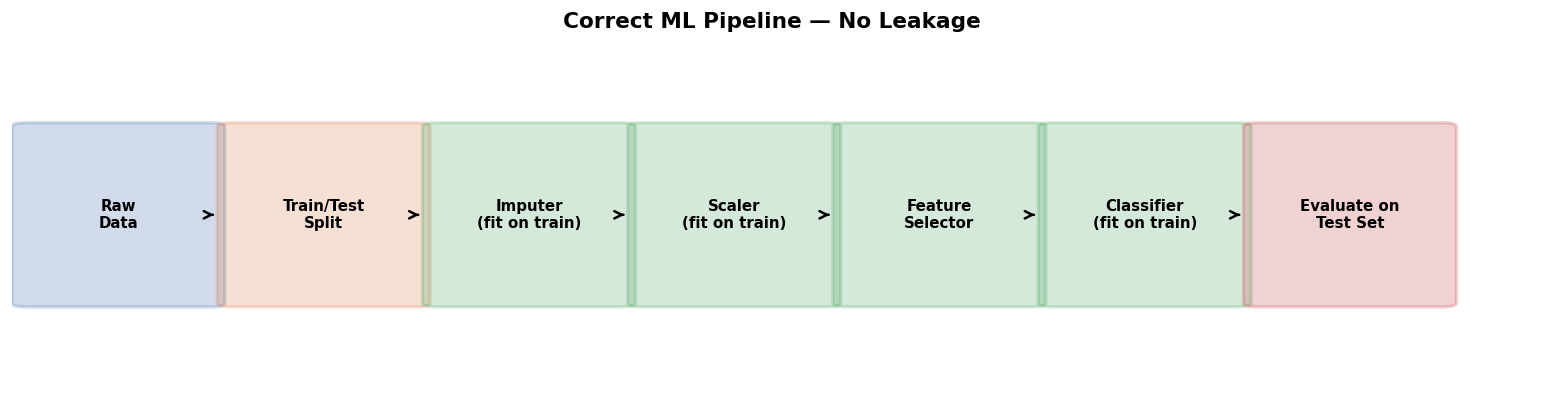

In [5]:
# ── Q4: Correct Pipeline Approach (Leakage-Free) ─────────────────────────────
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

X_raw, y_raw = make_classification(n_samples=600, n_features=15,
                                   n_informative=6, random_state=7)

# Introduce some missing values to demo imputation leakage
rng = np.random.RandomState(42)
mask = rng.rand(*X_raw.shape) < 0.1
X_raw[mask] = np.nan

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=42)

# ── WRONG: impute then split ──────────────────────────────────────────────────
imp_global = SimpleImputer(strategy='mean')
X_imp_all  = imp_global.fit_transform(X_raw)       # uses test set stats!
Xl2_tr, Xl2_te, yl2_tr, yl2_te = train_test_split(
    X_imp_all, y_raw, test_size=0.25, random_state=42)
m_leak2 = LogisticRegression(max_iter=500).fit(
    StandardScaler().fit_transform(Xl2_tr), yl2_tr)
score_leak2 = m_leak2.score(
    StandardScaler().fit(Xl2_tr).transform(Xl2_te), yl2_te)

# ── CORRECT: full Pipeline ────────────────────────────────────────────────────
clean_pipe = Pipeline([
    ('imputer',   SimpleImputer(strategy='mean')),     # fit only on X_r_train
    ('scaler',    StandardScaler()),
    ('selector',  SelectKBest(f_classif, k=8)),        # fit only on X_r_train
    ('clf',       LogisticRegression(max_iter=500))
])
clean_pipe.fit(X_r_train, y_r_train)
score_clean2 = clean_pipe.score(X_r_test, y_r_test)

# Cross-validate the clean pipeline
cv_scores = cross_val_score(clean_pipe, X_r_train, y_r_train,
                            cv=5, scoring='accuracy')

print('=== Leakage Prevention Demo ===')
print(f'Leaky (impute before split)  : Test Accuracy = {score_leak2:.4f}')
print(f'Clean Pipeline               : Test Accuracy = {score_clean2:.4f}')
print(f'Clean Pipeline (5-Fold CV)   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# ── Diagram: Pipeline flow ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis('off')

steps = [
    ('Raw\nData',   C1),
    ('Train/Test\nSplit', C2),
    ('Imputer\n(fit on train)', C3),
    ('Scaler\n(fit on train)', C3),
    ('Feature\nSelector', C3),
    ('Classifier\n(fit on train)', C3),
    ('Evaluate on\nTest Set', C4),
]

box_w, box_h = 0.12, 0.5
gap = 0.135
y_center = 0.5

for i, (label, color) in enumerate(steps):
    x = 0.01 + i * gap
    rect = mpatches.FancyBboxPatch((x, y_center - box_h/2), box_w, box_h,
                                   boxstyle='round,pad=0.01',
                                   facecolor=color, alpha=0.25,
                                   edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + box_w/2, y_center, label, ha='center', va='center',
            fontsize=9, fontweight='bold')
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + box_w + 0.005, y_center),
                    xytext=(x + box_w, y_center),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Correct ML Pipeline — No Leakage', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## Q5. The Confusion Matrix
### Theory

### What is a Confusion Matrix?

A **confusion matrix** is a table that summarizes the performance of a classification model by comparing **predicted labels** against **true labels**.

For a binary classifier:

```
                  PREDICTED
                Negative  Positive
ACTUAL Negative   TN        FP
       Positive   FN        TP
```

| Cell | Name | Meaning |
|---|---|---|
| **TP** | True Positive  | Correctly predicted Positive |
| **TN** | True Negative  | Correctly predicted Negative |
| **FP** | False Positive | Predicted Positive, actually Negative (Type I Error) |
| **FN** | False Negative | Predicted Negative, actually Positive (Type II Error) |

### What does it tell you?
- **Which classes** the model confuses
- **Type of errors** (FP vs FN) — critical in medical/legal domains
- **Class-wise performance** — not just overall accuracy
- **Foundation** for all other classification metrics

Confusion Matrix:
  TN (True Negative)  = 52  — Correctly predicted Malignant
  FP (False Positive) = 1  — Predicted Benign, actually Malignant
  FN (False Negative) = 1  — Predicted Malignant, actually Benign
  TP (True Positive)  = 89  — Correctly predicted Benign


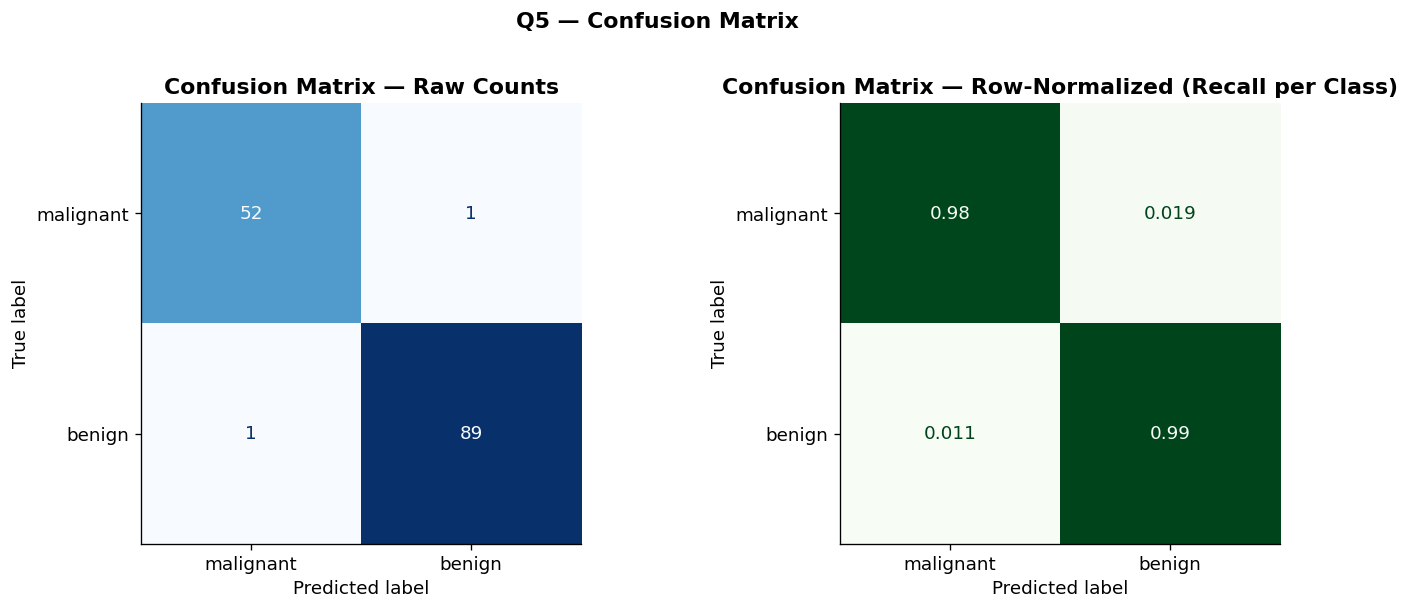


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [6]:
# ── Q5: Confusion Matrix Visualization ────────────────────────────────────────
# Train on breast cancer dataset
pipe_cm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])
pipe_cm.fit(X_train, y_train)
y_pred = pipe_cm.predict(X_test)
y_prob = pipe_cm.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print('Confusion Matrix:')
print(f'  TN (True Negative)  = {TN}  — Correctly predicted Malignant')
print(f'  FP (False Positive) = {FP}  — Predicted Benign, actually Malignant')
print(f'  FN (False Negative) = {FN}  — Predicted Malignant, actually Benign')
print(f'  TP (True Positive)  = {TP}  — Correctly predicted Benign')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Standard heatmap
disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Raw Counts')

# Normalized heatmap
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_n  = ConfusionMatrixDisplay(cm_norm, display_labels=data.target_names)
disp_n.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix — Row-Normalized (Recall per Class)')

plt.suptitle('Q5 — Confusion Matrix', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n' + classification_report(y_test, y_pred, target_names=data.target_names))

---
## Q6. Precision vs Recall
### Theory

### Precision
**"Of all the samples I predicted as Positive, how many were actually Positive?"**

$$\text{Precision} = \frac{TP}{TP + FP}$$

- High precision = few false alarms
- Critical when FP is costly (e.g., spam filter — don't block legitimate emails)

### Recall (Sensitivity / True Positive Rate)
**"Of all the actual Positives, how many did I correctly identify?"**

$$\text{Recall} = \frac{TP}{TP + FN}$$

- High recall = few missed positives
- Critical when FN is costly (e.g., cancer screening — don't miss any cancer case)

### The Precision-Recall Trade-off
As you **lower** the classification threshold:
- More samples predicted as Positive → **Recall increases** but **Precision decreases**

As you **raise** the threshold:
- Fewer samples predicted as Positive → **Precision increases** but **Recall decreases**

| Metric | Formula | Optimise when |
|---|---|---|
| Precision | TP / (TP+FP) | FP cost is high (spam, fraud alerts) |
| Recall | TP / (TP+FN) | FN cost is high (disease detection) |
| F1-Score | 2·P·R/(P+R) | Balance between both is needed |

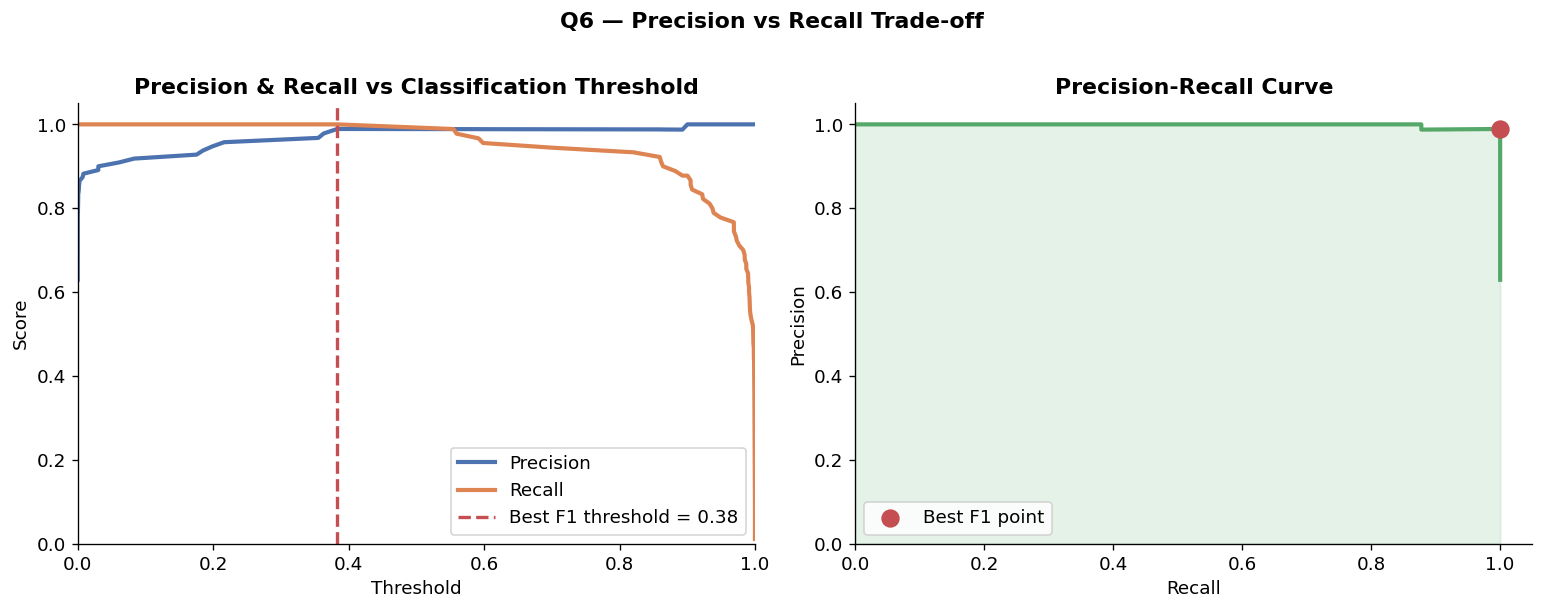

At default threshold (0.5):
  Precision = 0.9889
  Recall    = 0.9889
  F1-Score  = 0.9889


In [7]:
# ── Q6: Precision-Recall Trade-off ────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob)

# Find threshold that maximises F1
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
best_t = thresh_arr[np.argmax(f1_arr)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision & Recall vs Threshold
ax = axes[0]
ax.plot(thresh_arr, prec_arr[:-1], lw=2.5, color=C1, label='Precision')
ax.plot(thresh_arr, rec_arr[:-1],  lw=2.5, color=C2, label='Recall')
ax.axvline(best_t, color=C4, ls='--', lw=2,
           label=f'Best F1 threshold = {best_t:.2f}')
ax.set(title='Precision & Recall vs Classification Threshold',
       xlabel='Threshold', ylabel='Score', xlim=[0, 1], ylim=[0, 1.05])
ax.legend()

# Precision-Recall Curve
ax = axes[1]
ax.plot(rec_arr, prec_arr, lw=2.5, color=C3)
ax.fill_between(rec_arr, prec_arr, alpha=0.15, color=C3)
ax.scatter([rec_arr[np.argmax(f1_arr)]], [prec_arr[np.argmax(f1_arr)]],
           s=100, color=C4, zorder=5, label=f'Best F1 point')
ax.set(title='Precision-Recall Curve',
       xlabel='Recall', ylabel='Precision', xlim=[0, 1.05], ylim=[0, 1.05])
ax.legend()

plt.suptitle('Q6 — Precision vs Recall Trade-off', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

p = precision_score(y_test, y_pred)
r = recall_score(y_test, y_pred)
f = f1_score(y_test, y_pred)
print(f'At default threshold (0.5):')
print(f'  Precision = {p:.4f}')
print(f'  Recall    = {r:.4f}')
print(f'  F1-Score  = {f:.4f}')

---
## Q7. Interpreting Confusion Matrix — Types of Errors
### Theory

### Reading the Confusion Matrix:

- **Diagonal cells (TN, TP):** Correct predictions — want these to be large
- **Off-diagonal cells (FP, FN):** Errors — want these to be small

### Error Types & Their Consequences:

| Error | Also called | What happened | Real-world consequence |
|---|---|---|---|
| **FP** | Type I Error | Predicted Positive, actually Negative | Unnecessary cancer biopsy; spam filter blocks real email |
| **FN** | Type II Error | Predicted Negative, actually Positive | Missed cancer diagnosis; fraud transaction approved |

### Multiclass Confusion Matrix:
Extend to N×N matrix. Row = Actual class, Column = Predicted class.  
**Off-diagonal elements** show which classes are confused with each other.

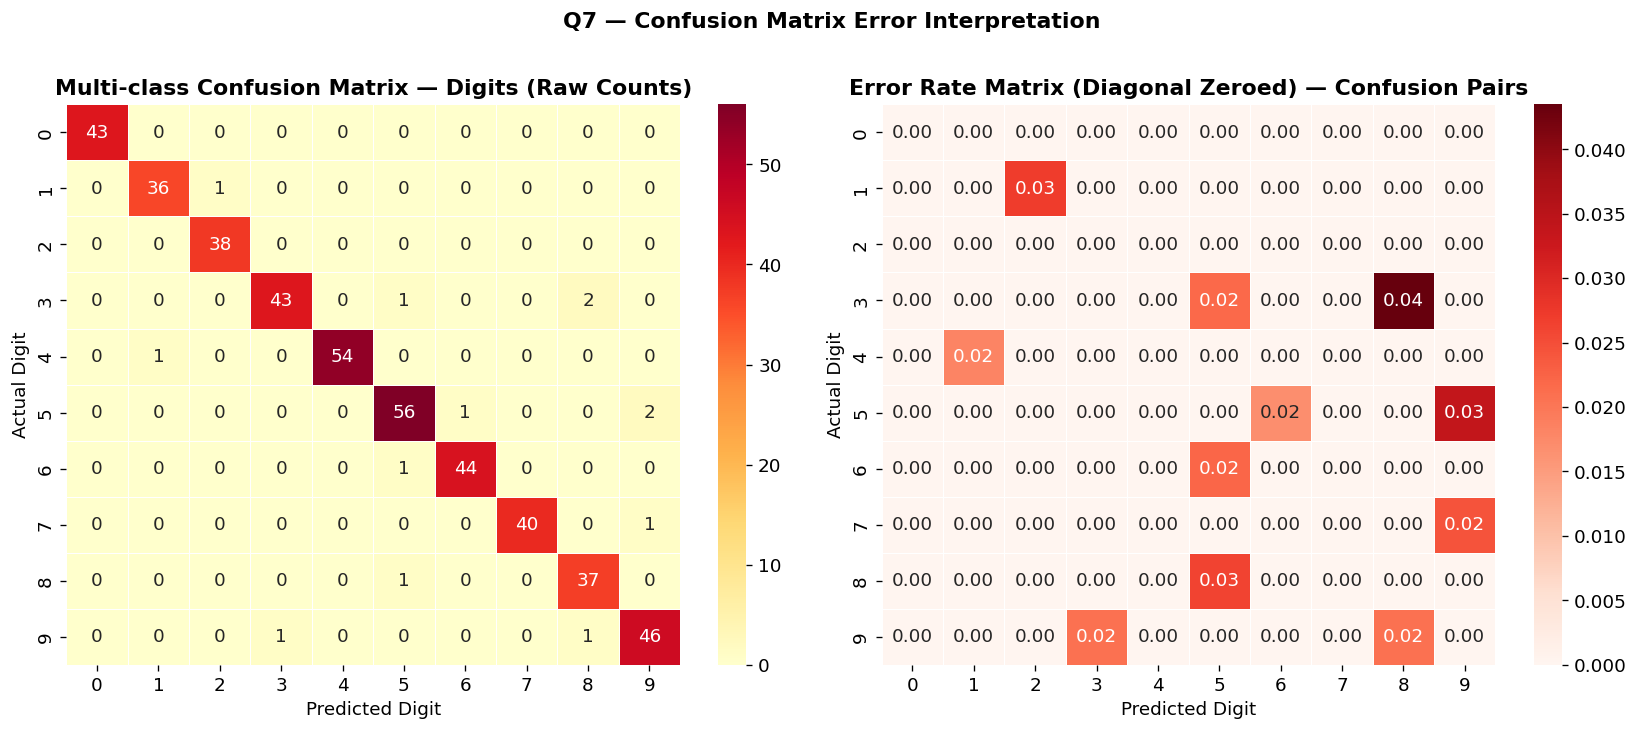

Most confused digit pairs (error rate > 5%):


In [8]:
# ── Q7: Error Analysis — Multi-class Confusion Matrix ─────────────────────────
digits = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    digits.data, digits.target, test_size=0.25, random_state=42)

pipe_digits = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=2000, random_state=42))
])
pipe_digits.fit(Xd_tr, yd_tr)
yd_pred = pipe_digits.predict(Xd_te)

cm_digits = confusion_matrix(yd_te, yd_pred)
cm_digits_norm = cm_digits.astype(float) / cm_digits.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_digits, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.3,
            xticklabels=range(10), yticklabels=range(10))
axes[0].set(title='Multi-class Confusion Matrix — Digits (Raw Counts)',
            xlabel='Predicted Digit', ylabel='Actual Digit')

# Highlight confusion pairs
np.fill_diagonal(cm_digits_norm, 0)  # zero out diagonal to highlight errors
sns.heatmap(cm_digits_norm, annot=True, fmt='.2f', cmap='Reds',
            ax=axes[1], linewidths=0.3,
            xticklabels=range(10), yticklabels=range(10))
axes[1].set(title='Error Rate Matrix (Diagonal Zeroed) — Confusion Pairs',
            xlabel='Predicted Digit', ylabel='Actual Digit')

plt.suptitle('Q7 — Confusion Matrix Error Interpretation',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Find most confused pairs
rows, cols = np.where(cm_digits_norm > 0.05)
pairs = [(cm_digits_norm[r, c], r, c) for r, c in zip(rows, cols)]
pairs.sort(reverse=True)
print('Most confused digit pairs (error rate > 5%):')
for rate, actual, pred in pairs[:6]:
    print(f'  Actual={actual} predicted as {pred}: {rate*100:.1f}% of actual {actual}s')

---
## Q8. Metrics Derived from the Confusion Matrix
### Theory

| Metric | Formula | Range | Best when |
|---|---|---|---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | [0,1] | Balanced classes |
| **Precision** | TP/(TP+FP) | [0,1] | FP cost high |
| **Recall** | TP/(TP+FN) | [0,1] | FN cost high |
| **F1-Score** | 2·P·R/(P+R) | [0,1] | Imbalanced classes |
| **Specificity** | TN/(TN+FP) | [0,1] | Negative class matters |
| **FPR** | FP/(FP+TN) | [0,1] | ROC curve x-axis |
| **MCC** | (TP·TN−FP·FN)/√(...) | [-1,1] | Robust to imbalance |
| **Balanced Accuracy** | (Recall+Specificity)/2 | [0,1] | Imbalanced classes |

**Matthews Correlation Coefficient (MCC)** — most informative single metric:
$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

=== All Metrics from Confusion Matrix ===
  TN=52, FP=1, FN=1, TP=89

  Accuracy                 : 0.9860
  Precision                : 0.9889
  Recall (Sensitivity)     : 0.9889
  Specificity              : 0.9811
  F1-Score                 : 0.9889
  Balanced Accuracy        : 0.9850
  MCC                      : 0.9700
  FPR (Type I Rate)        : 0.0189
  FNR (Type II Rate)       : 0.0111
  ROC-AUC                  : 0.9977


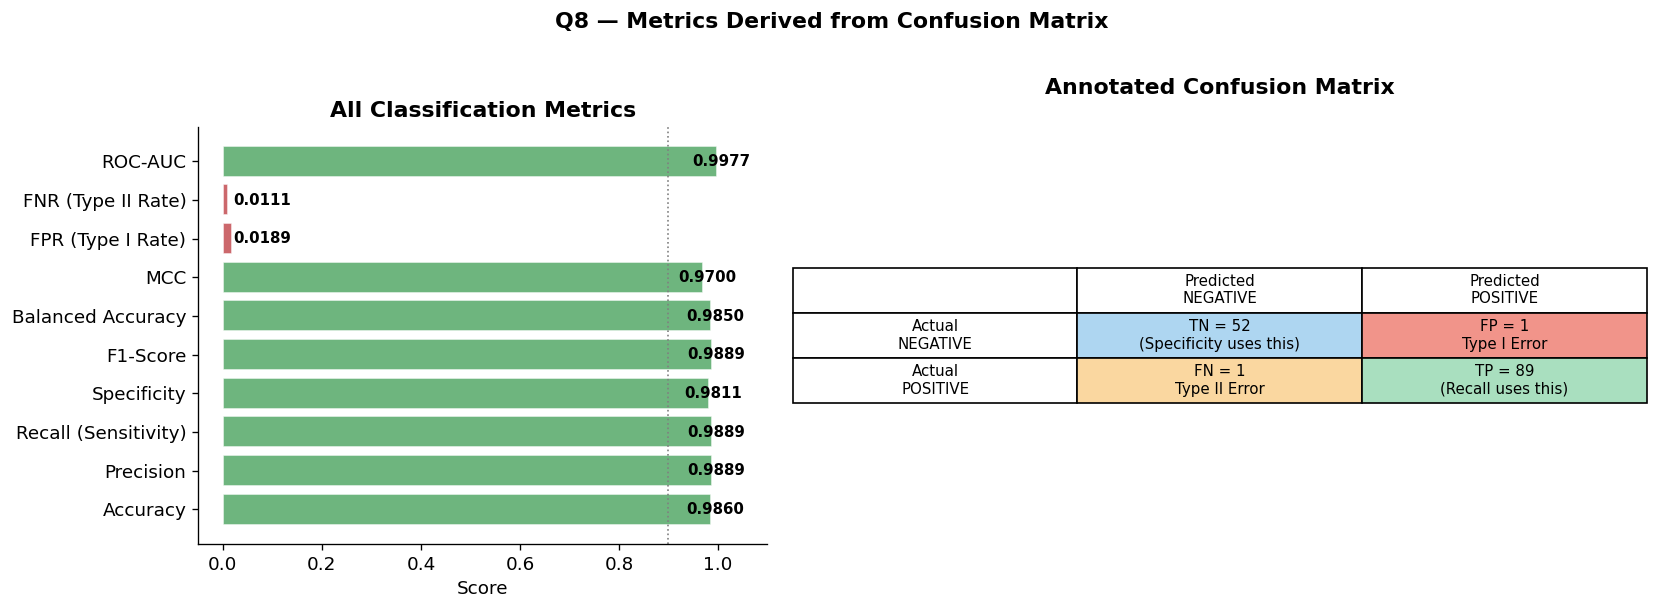

In [9]:
# ── Q8: All Metrics Derived from Confusion Matrix ─────────────────────────────
def compute_all_metrics(y_true, y_pred, y_prob=None):
    cm_vals = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm_vals.ravel()
    metrics = {
        'Accuracy'         : (tp+tn)/(tp+tn+fp+fn),
        'Precision'        : tp/(tp+fp) if (tp+fp)>0 else 0,
        'Recall (Sensitivity)': tp/(tp+fn) if (tp+fn)>0 else 0,
        'Specificity'      : tn/(tn+fp) if (tn+fp)>0 else 0,
        'F1-Score'         : f1_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'MCC'              : matthews_corrcoef(y_true, y_pred),
        'FPR (Type I Rate)': fp/(fp+tn) if (fp+tn)>0 else 0,
        'FNR (Type II Rate)': fn/(fn+tp) if (fn+tp)>0 else 0,
    }
    if y_prob is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return metrics, (tn, fp, fn, tp)

metrics, (tn, fp, fn, tp) = compute_all_metrics(y_test, y_pred, y_prob)

print('=== All Metrics from Confusion Matrix ===')
print(f'  TN={tn}, FP={fp}, FN={fn}, TP={tp}\n')
for name, val in metrics.items():
    print(f'  {name:<25}: {val:.4f}')

# ── Radar / Spider chart of metrics ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
m_names = list(metrics.keys())
m_vals  = list(metrics.values())
bar_colors = [C3 if v >= 0.95 else C2 if v >= 0.85 else C4 for v in m_vals]
bars = ax.barh(m_names, m_vals, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, m_vals):
    ax.text(max(v - 0.05, 0.02), bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set(title='All Classification Metrics',
       xlabel='Score', xlim=[-0.05, 1.1])
ax.axvline(0.9, color='grey', ls=':', lw=1)

# Annotated confusion matrix with formula overlay
ax = axes[1]
ax.axis('off')
cell_data = [
    ['', 'Predicted\nNEGATIVE', 'Predicted\nPOSITIVE'],
    ['Actual\nNEGATIVE', f'TN = {tn}\n(Specificity uses this)', f'FP = {fp}\nType I Error'],
    ['Actual\nPOSITIVE', f'FN = {fn}\nType II Error', f'TP = {tp}\n(Recall uses this)']
]
tbl = ax.table(cellText=cell_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.5, 2.5)

# Color cells
cell_colors = {
    (1,1): '#AED6F1', (2,2): '#A9DFBF',   # TN=blue, TP=green
    (1,2): '#F1948A', (2,1): '#FAD7A0',   # FP=red, FN=orange
}
for (r, c), col in cell_colors.items():
    tbl[r, c].set_facecolor(col)

ax.set_title('Annotated Confusion Matrix', fontweight='bold', pad=20)

plt.suptitle('Q8 — Metrics Derived from Confusion Matrix', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Q9. Relationship Between Accuracy and the Confusion Matrix
### Theory

### Accuracy from the Confusion Matrix:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$$

### Why Accuracy Can Be Misleading:

Consider a dataset with **95% class 0** and **5% class 1** (imbalanced):
- A model that **always predicts class 0** achieves **95% accuracy**
- But it has **0% recall** for the minority class — it's completely useless!

| Scenario | TP | TN | FP | FN | Accuracy | F1 |
|---|---|---|---|---|---|---|
| Perfect model | 50 | 950 | 0 | 0 | 100% | 100% |
| Always predicts 0 | 0 | 950 | 0 | 50 | 95% | 0% |
| Random | ~5 | ~900 | ~50 | ~45 | ~90% | ~10% |

### Key Insight:
> Accuracy = sum of the diagonal / sum of all elements in the confusion matrix.  
> For imbalanced datasets, **accuracy is an unreliable metric** — always check the full confusion matrix.

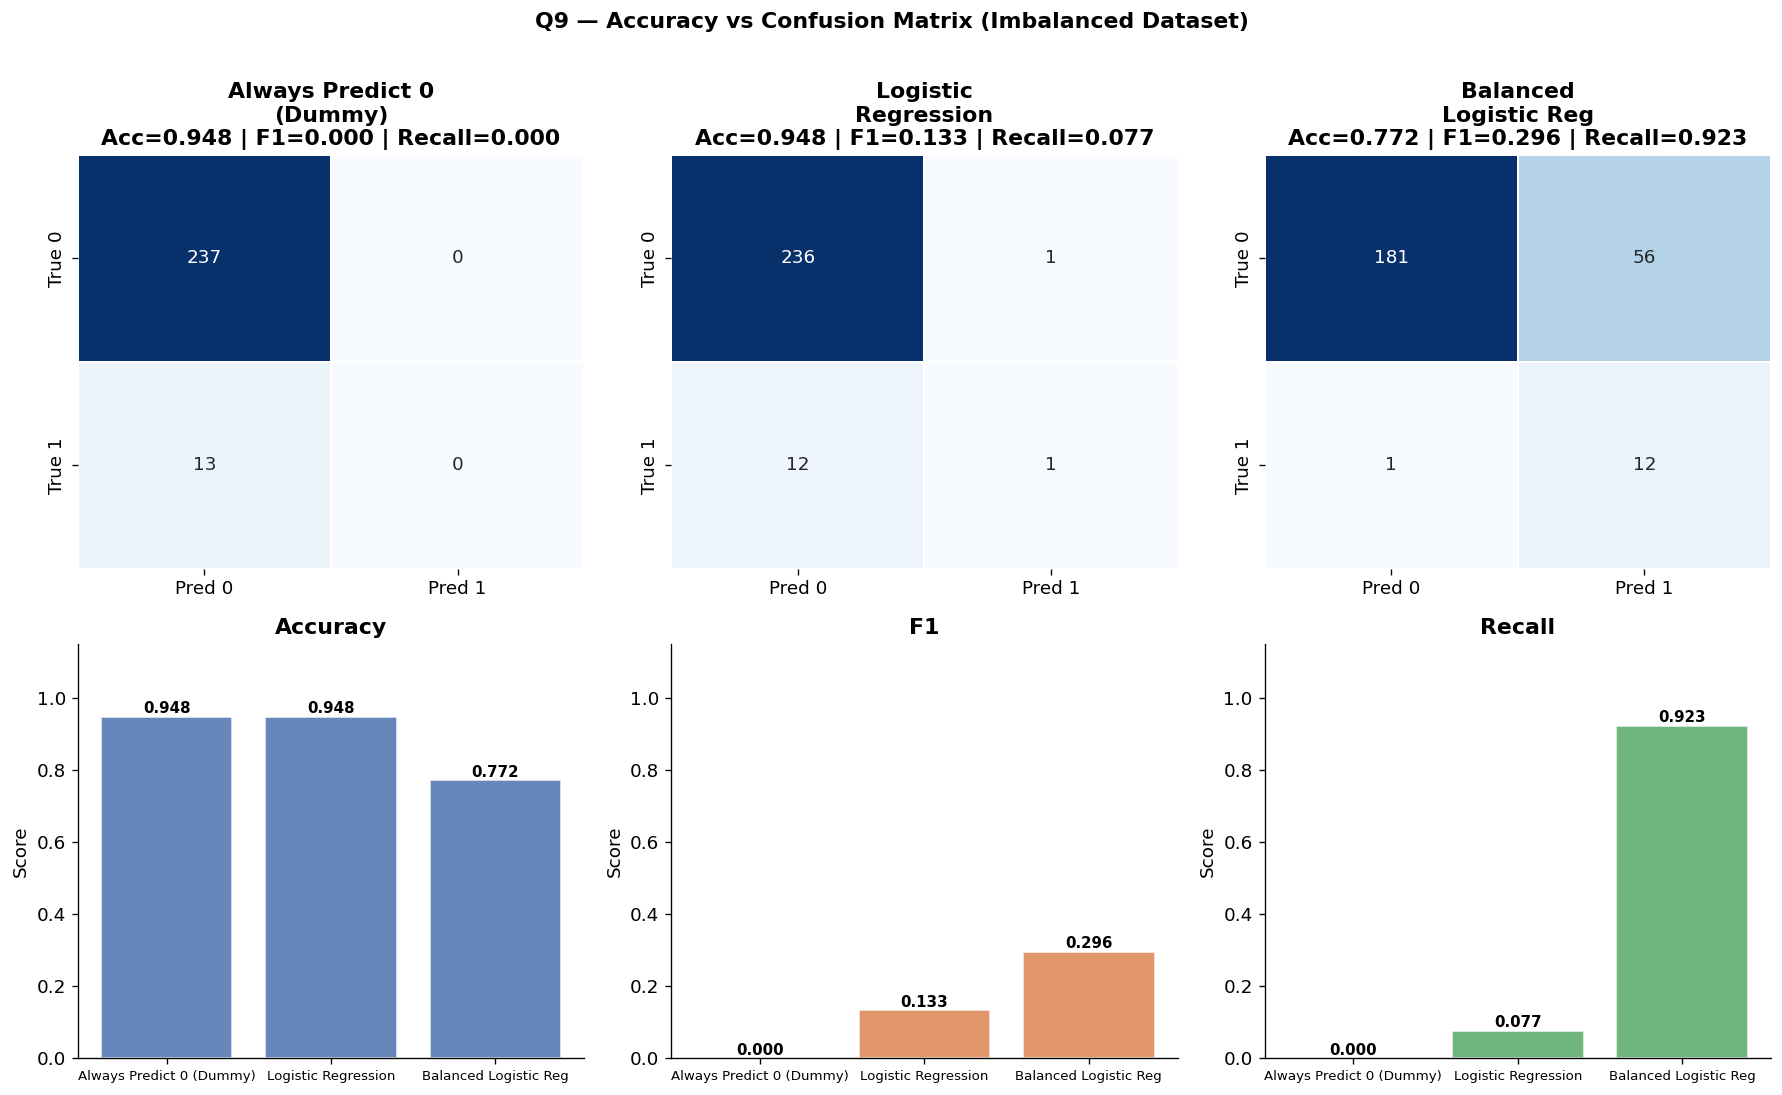

Key takeaway: Dummy classifier achieves 95% accuracy but 0% F1 and 0% Recall!
Always examine the full confusion matrix, not just accuracy.


In [10]:
# ── Q9: Accuracy vs Confusion Matrix — Imbalanced Example ─────────────────────
from sklearn.dummy import DummyClassifier

# Create imbalanced dataset (5% positive)
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, weights=[0.95, 0.05],
    n_informative=5, random_state=42)

Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42, stratify=y_imb)

models_q9 = {
    'Always Predict 0\n(Dummy)': DummyClassifier(strategy='constant', constant=0),
    'Logistic\nRegression':      Pipeline([('s', StandardScaler()),
                                           ('c', LogisticRegression(max_iter=1000))]),
    'Balanced\nLogistic Reg':    Pipeline([('s', StandardScaler()),
                                           ('c', LogisticRegression(
                                               class_weight='balanced', max_iter=1000))]),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
results_q9 = {}

for idx, (name, mdl) in enumerate(models_q9.items()):
    mdl.fit(Xi_tr, yi_tr)
    yp = mdl.predict(Xi_te)
    cm_i = confusion_matrix(yi_te, yp)
    acc  = accuracy_score(yi_te, yp)
    f1   = f1_score(yi_te, yp, zero_division=0)
    rec  = recall_score(yi_te, yp, zero_division=0)

    results_q9[name.replace('\n', ' ')] = {
        'Accuracy': acc, 'F1': f1, 'Recall': rec}

    # Top row: confusion matrices
    ax = axes[0, idx]
    sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                ax=ax, linewidths=1, cbar=False,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    ax.set_title(f'{name}\nAcc={acc:.3f} | F1={f1:.3f} | Recall={rec:.3f}')

# Bottom row: metric comparison
names  = [k.replace('\n', ' ') for k in models_q9.keys()]
metric_labels = ['Accuracy', 'F1', 'Recall']
colors_q9 = [C1, C2, C3]

for j, (mlbl, col) in enumerate(zip(metric_labels, colors_q9)):
    ax = axes[1, j]
    vals = [results_q9[n][mlbl] for n in names]
    bars = ax.bar(names, vals, color=col, alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
                ha='center', fontweight='bold', fontsize=9)
    ax.set(title=mlbl, ylabel='Score', ylim=[0, 1.15])
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Q9 — Accuracy vs Confusion Matrix (Imbalanced Dataset)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Key takeaway: Dummy classifier achieves 95% accuracy but 0% F1 and 0% Recall!')
print('Always examine the full confusion matrix, not just accuracy.')

---
## Q10. Using Confusion Matrix to Identify Bias and Limitations
### Theory

### How the Confusion Matrix Reveals Bias:

| Pattern | Bias/Limitation Indicated |
|---|---|
| High FN for one class | Model under-detects a subgroup — likely undertrained on it |
| High FP for one class | Model over-predicts a subgroup — may reflect training data bias |
| Near-zero TP for minority class | Model effectively ignores the minority class entirely |
| Asymmetric confusion between classes | Training data may have unequal representation or mislabelling |
| Per-subgroup CM differences | Model performs differently across demographics — **fairness issue** |

### Strategies to investigate and mitigate:
1. **Slice the confusion matrix** by subgroup (age, gender, region)
2. **Compare per-class recall** — equal opportunity requires equal recall across groups
3. **Check class distribution** in training data vs test data
4. **Use fairness metrics**: Equalized Odds, Demographic Parity, Calibration
5. **Audit labeling** — mislabeled data creates systematic confusion

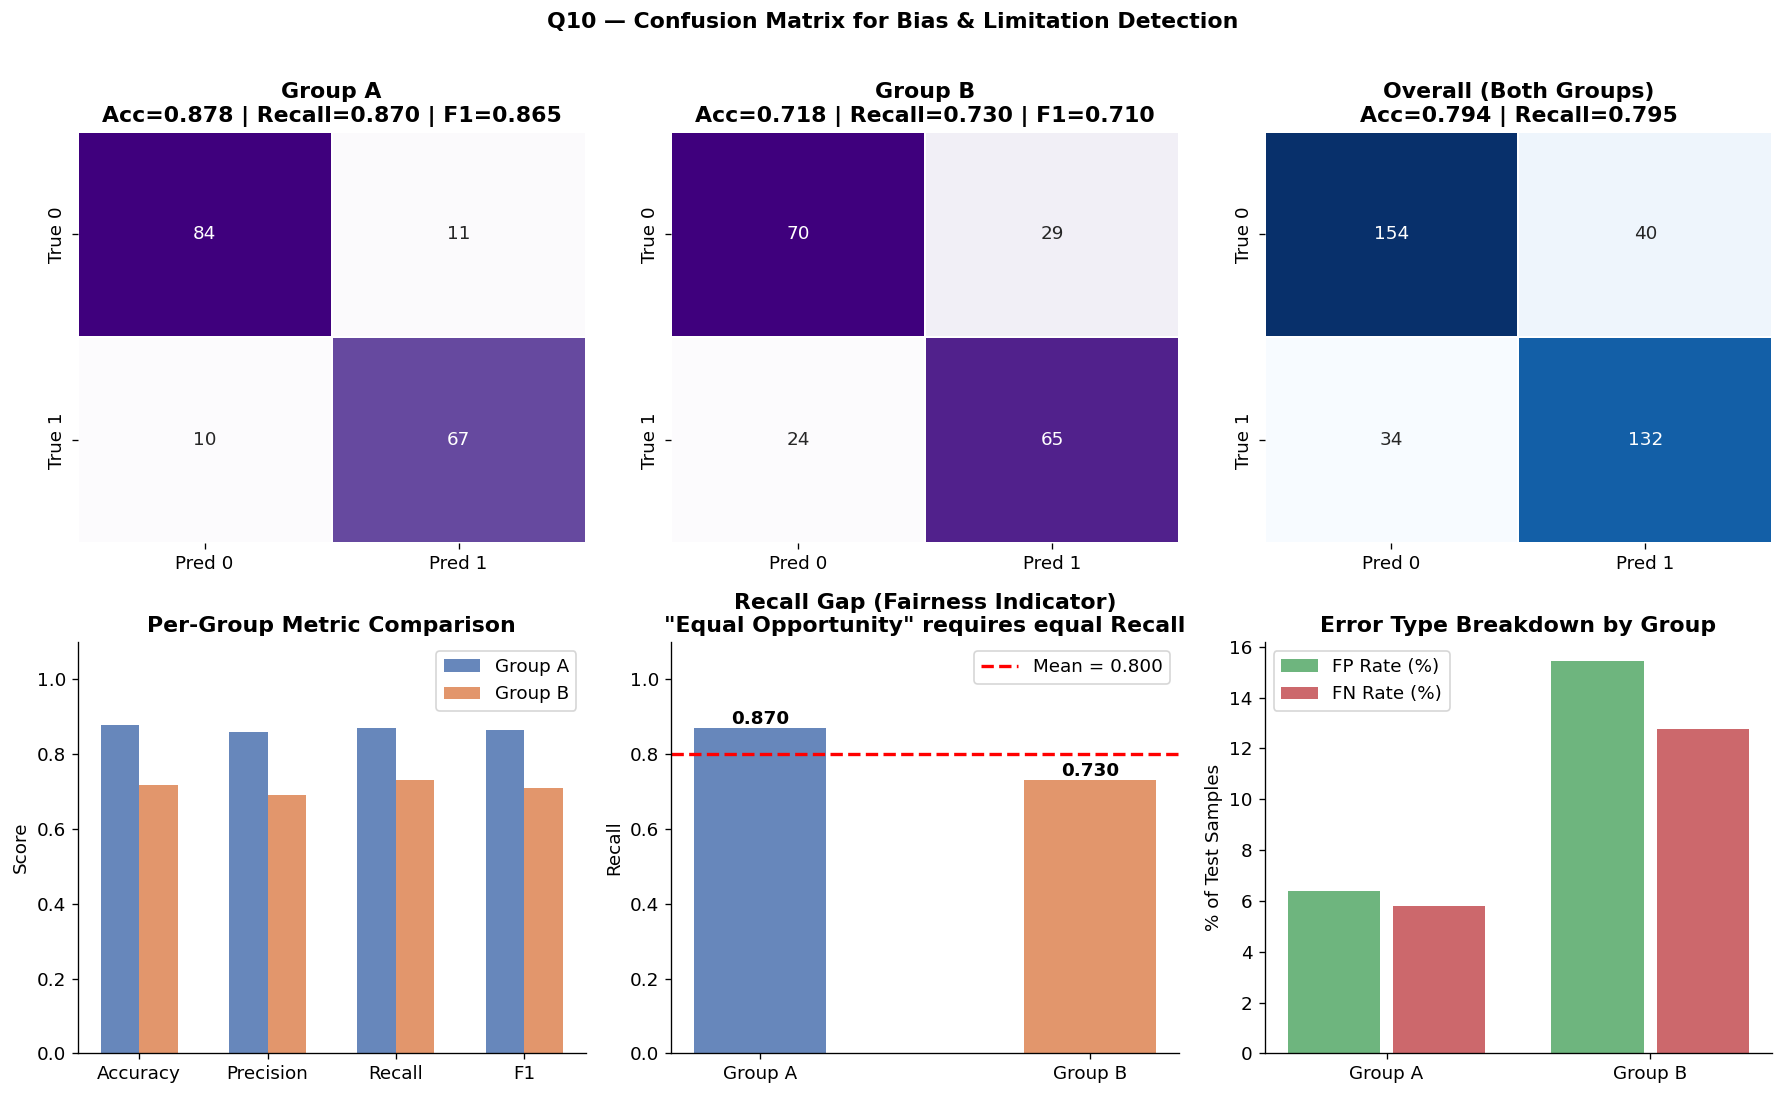

Recall Gap between groups: 0.140
  Group A Recall: 0.870
  Group B Recall: 0.730
⚠  Significant recall disparity detected — model may be biased!


In [11]:
# ── Q10: Bias Detection via Per-Subgroup Confusion Matrices ───────────────────
np.random.seed(42)
n = 1200

# Simulate biased dataset: Group A has more positive examples
group = np.random.choice(['Group A', 'Group B'], size=n, p=[0.5, 0.5])
X_bias = np.random.randn(n, 5)
# Group A: feature 0 strongly predictive; Group B: feature 0 weaker
signal = np.where(group == 'Group A', X_bias[:, 0] * 2, X_bias[:, 0] * 0.5)
y_bias = (signal + np.random.randn(n) * 0.8 > 0).astype(int)

Xb_tr, Xb_te, yb_tr, yb_te, grp_tr, grp_te = train_test_split(
    X_bias, y_bias, group,
    test_size=0.3, random_state=42)

# Train a single model on all groups
pipe_bias = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=500, random_state=42))
])
pipe_bias.fit(Xb_tr, yb_tr)
yb_pred = pipe_bias.predict(Xb_te)

groups = ['Group A', 'Group B']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

group_metrics = {}

for idx, grp in enumerate(groups):
    mask = grp_te == grp
    yt_g, yp_g = yb_te[mask], yb_pred[mask]
    cm_g = confusion_matrix(yt_g, yp_g)

    acc_g = accuracy_score(yt_g, yp_g)
    rec_g = recall_score(yt_g, yp_g, zero_division=0)
    pre_g = precision_score(yt_g, yp_g, zero_division=0)
    f1_g  = f1_score(yt_g, yp_g, zero_division=0)
    group_metrics[grp] = {'Accuracy':acc_g,'Precision':pre_g,
                          'Recall':rec_g,'F1':f1_g}

    # Confusion matrix
    ax = axes[0, idx]
    sns.heatmap(cm_g, annot=True, fmt='d', cmap='Purples',
                ax=ax, linewidths=1, cbar=False,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    ax.set_title(f'{grp}\nAcc={acc_g:.3f} | Recall={rec_g:.3f} | F1={f1_g:.3f}')

# Overall confusion matrix
cm_all = confusion_matrix(yb_te, yb_pred)
ax = axes[0, 2]
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues',
            ax=ax, linewidths=1, cbar=False,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['True 0','True 1'])
acc_all = accuracy_score(yb_te, yb_pred)
rec_all = recall_score(yb_te, yb_pred)
ax.set_title(f'Overall (Both Groups)\nAcc={acc_all:.3f} | Recall={rec_all:.3f}')

# Per-group metric comparison
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_names))
w = 0.3

ax = axes[1, 0]
for i, (grp, col) in enumerate(zip(groups, [C1, C2])):
    vals = [group_metrics[grp][m] for m in metric_names]
    bars = ax.bar(x + i*w, vals, w, label=grp, color=col, alpha=0.85)
ax.set(title='Per-Group Metric Comparison',
       xticks=x+w/2, xticklabels=metric_names, ylabel='Score', ylim=[0, 1.1])
ax.legend()

# Recall gap — key fairness indicator
ax = axes[1, 1]
recall_vals = [group_metrics[g]['Recall'] for g in groups]
bars = ax.bar(groups, recall_vals, color=[C1, C2], alpha=0.85, width=0.4)
for b, v in zip(bars, recall_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
            ha='center', fontweight='bold')
ax.axhline(np.mean(recall_vals), color='red', ls='--', lw=2,
           label=f'Mean = {np.mean(recall_vals):.3f}')
ax.set(title='Recall Gap (Fairness Indicator)\n"Equal Opportunity" requires equal Recall',
       ylabel='Recall', ylim=[0, 1.1])
ax.legend()

# Error type breakdown
ax = axes[1, 2]
error_data = {}
for grp in groups:
    mask = grp_te == grp
    cm_g = confusion_matrix(yb_te[mask], yb_pred[mask])
    tn, fp, fn, tp = cm_g.ravel()
    total = tn+fp+fn+tp
    error_data[grp] = {'FP Rate': fp/total*100, 'FN Rate': fn/total*100}

x2 = np.arange(2)
fp_vals = [error_data[g]['FP Rate'] for g in groups]
fn_vals = [error_data[g]['FN Rate'] for g in groups]
ax.bar(x2 - 0.2, fp_vals, 0.35, label='FP Rate (%)', color=C3, alpha=0.85)
ax.bar(x2 + 0.2, fn_vals, 0.35, label='FN Rate (%)', color=C4, alpha=0.85)
ax.set(title='Error Type Breakdown by Group',
       xticks=x2, xticklabels=groups, ylabel='% of Test Samples')
ax.legend()

plt.suptitle('Q10 — Confusion Matrix for Bias & Limitation Detection',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

recall_gap = abs(recall_vals[0] - recall_vals[1])
print(f'Recall Gap between groups: {recall_gap:.3f}')
print(f'  Group A Recall: {recall_vals[0]:.3f}')
print(f'  Group B Recall: {recall_vals[1]:.3f}')
if recall_gap > 0.05:
    print('⚠  Significant recall disparity detected — model may be biased!')
else:
    print('✓  Recall is approximately equal across groups.')